# Post-TARE Adoption KPIs: Bill Savings & Demand Change
**Author:** Jordan M. Joseph, PhD â€” Carnegie Mellon University

Computes bill savings ratio and electricity demand change metrics from TARE model outputs and EUSS data.

In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import VALID_MENU_MPS
from cmu_tare_model.utils.load_exported_results_to_df import load_measure_package_data

from cmu_tare_model.adoption_kpis import (
    load_euss_baseline, load_euss_upgrade, mp_to_upgrade,
    compute_scenario_demand, aggregate_demand,
    compute_bill_savings_ratio, aggregate_bill_savings,
)
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe, create_choropleth_map, plot_combined_choropleth,
)
from cmu_tare_model.adoption_kpis.data_loading import (
    FUEL_PRICES_PATH, SHAPEFILE_PATH,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
SAVE_FIGURES = False  # Set to True to save figure files to disk

print("[OK] Imports loaded")


Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
[OK] Imports loaded


In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"Selected measure packages: {selected_mps}")

Available measure packages: [3, 4]
Selected measure packages: [3, 4]


In [3]:
# Load TARE model outputs for selected measure packages.
# These contain per-building lifetime fuel costs used for bill savings ratio.

try:
    _ = DATAFRAMES_BY_MP
    print(f"DATAFRAMES_BY_MP already loaded: {list(DATAFRAMES_BY_MP.keys())}")
except NameError:
    try:
        _ = output_folder_path
        print(f"Using existing output_folder_path: {output_folder_path}")
    except NameError:
        output_folder_path = os.path.join(PROJECT_ROOT, "cmu_tare_model", "output_results")
        location_id = input("Enter location ID (e.g., 'National' or 'PA'): ").strip()
        model_run_date_time = input("Enter model run timestamp (YYYY-MM-DD_HH-MM): ").strip()

    DATAFRAMES_BY_MP = {}
    for mp in selected_mps:
        DATAFRAMES_BY_MP[mp] = load_measure_package_data(
            mp, output_folder_path, location_id, model_run_date_time
        )
    print(f"[OK] Loaded TARE data for MPs: {list(DATAFRAMES_BY_MP.keys())}")

Loading MP3 data...
  fixed_base: ✓ 
MP3 loading complete!

Loading MP4 data...
  fixed_base: ✓ 
MP4 loading complete!

[OK] Loaded TARE data for MPs: [3, 4]


In [4]:
df_baseline = load_euss_baseline()
print(f"Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n[OK] EUSS data loaded")

Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:180: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:214: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:214: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP4: 331,526 applicable homes

[OK] EUSS data loaded


In [5]:
bill_savings_results = {}
for mp in selected_mps:
    print(f"\n{'='*60}")
    print(f"BILL SAVINGS RATIO — MP{mp}, all fuels")
    print(f"{'='*60}")
    df_tare = DATAFRAMES_BY_MP[mp]['fixed_base']['inmap']
    df_ratio = compute_bill_savings_ratio(
        df_tare, mp=mp, policy_scenario='iraRef',
        fuel_filter=None, verbose=True,
        df_euss=df_baseline,
    )
    df_ratio_state = aggregate_bill_savings(df_ratio, verbose=True)
    bill_savings_results[mp] = df_ratio_state

print("\n[OK] Bill savings ratio complete")



BILL SAVINGS RATIO — MP3, all fuels
Per-building records (non-null ratio): 280,250
Median bill savings ratio: 0.725
Mean bill savings ratio:   0.919
States where median home saves money (ratio < 1): 46 / 49
National median of states medians: 0.653

BILL SAVINGS RATIO — MP4, all fuels
Per-building records (non-null ratio): 280,250
Median bill savings ratio: 0.449
Mean bill savings ratio:   0.470
States where median home saves money (ratio < 1): 49 / 49
National median of states medians: 0.440

[OK] Bill savings ratio complete


In [6]:
for mp, df_state in bill_savings_results.items():
    print(f"\n===== BILL SAVINGS RATIO (MP{mp}, NG homes) =====")
    n_savings = (df_state['median_bill_savings_ratio'] < 1.0).sum()
    print(f"States where median home saves money: {n_savings} / {len(df_state)}")
    print(f"National median: {df_state['median_bill_savings_ratio'].median():.3f}")
    print(f"\nTop 5 (best for electrification):")
    print(df_state.nsmallest(5, 'median_bill_savings_ratio')[
        ['state', 'median_bill_savings_ratio', 'weighted_ratio', 'home_count']
    ].to_string(index=False))
    print(f"\nBottom 5 (worst for electrification):")
    print(df_state.nlargest(5, 'median_bill_savings_ratio')[
        ['state', 'median_bill_savings_ratio', 'weighted_ratio', 'home_count']
    ].to_string(index=False))


===== BILL SAVINGS RATIO (MP3, NG homes) =====
States where median home saves money: 46 / 49
National median: 0.653

Top 5 (best for electrification):
state  median_bill_savings_ratio  weighted_ratio  home_count
   FL                      0.373           0.395       19937
   LA                      0.420           0.439        4911
   VT                      0.439           0.507         716
   ME                      0.440           0.475        1580
   NC                      0.450           0.394       11087

Bottom 5 (worst for electrification):
state  median_bill_savings_ratio  weighted_ratio  home_count
   NJ                      1.244           0.865        8391
   MI                      1.131           1.030       12391
   CA                      1.048           0.774       34443
   NY                      0.958           0.709       13987
   IN                      0.946           0.761        8124

===== BILL SAVINGS RATIO (MP4, NG homes) =====
States where median home save

In [7]:
demand_results = {}
for mp in selected_mps:
    print(f"\n{'='*60}")
    print(f"DEMAND CHANGE — MP{mp}, all fuels, 100% adoption")
    print(f"{'='*60}")
    df_demand = compute_scenario_demand(
        df_baseline, upgrade_data[mp], fuel_filter=None, verbose=True,
    )
    df_demand_state = aggregate_demand(df_demand, verbose=True)
    demand_results[mp] = df_demand_state

print("\n[OK] Demand change complete")



DEMAND CHANGE — MP3, all fuels, 100% adoption

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +427,043.7 GWh (grid impact)
Weighted total site energy change:   +427,043.7 GWh (efficiency)
✓ Demand accounting check passed

--- State-Level Demand Summary ---
States: 49
Total elec demand change:    +427043.7 GWh (grid impact)

DEMAND CHANGE — MP4, all fuels, 100% adoption

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +30,618.3 GWh (grid impact)
Weighted total site energy change:   +30,618.3 GWh (efficiency)
✓ Demand accounting check passed

--- State-Level Demand Summary ---
States: 49
Total elec demand change:    +30618.3 GWh (grid impact)

[OK] Demand change complete


In [8]:
for mp, df_state in demand_results.items():
    print(f"\n===== DEMAND CHANGE (MP{mp}, GWh, all fuels, 100% adoption) =====")
    print(f"Total elec demand change: {df_state['elec_change_gwh'].sum():+.1f} GWh")
    print(f"Total site energy change: {df_state['site_energy_change_gwh'].sum():+.1f} GWh")
    print(f"\nTop 5 (largest elec demand increase):")
    print(df_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                     'site_energy_change_gwh', 'pct_site_energy_change']].head(5).to_string(index=False))
    print(f"\nBottom 5:")
    print(df_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                     'site_energy_change_gwh', 'pct_site_energy_change']].tail(5).to_string(index=False))


===== DEMAND CHANGE (MP3, GWh, all fuels, 100% adoption) =====
Total elec demand change: +427043.7 GWh
Total site energy change: +427043.7 GWh

Top 5 (largest elec demand increase):
state  elec_change_gwh  pct_elec_demand_change  site_energy_change_gwh  pct_site_energy_change
   NY         49369.55                  136.36                49369.55                  136.36
   MI         46069.15                  154.37                46069.15                  154.37
   IL         39568.63                  112.39                39568.63                  112.39
   OH         34294.05                   81.41                34294.05                   81.41
   PA         33809.93                   72.38                33809.93                   72.38

Bottom 5:
state  elec_change_gwh  pct_elec_demand_change  site_energy_change_gwh  pct_site_energy_change
   AL         -1693.26                   -6.74                -1693.26                   -6.74
   LA         -1753.21                   -7.91

[OK] Shapefile loaded: 52 features
Bill savings ratio norm: [0.197, 1.0, 1.244]
Bill savings % norm: [-77.6, 0, 3.0]%
Demand GWh norm: [-33002.0, 0, 49369.6] GWh
Demand % norm: [-29.8, 0, 212.2]%


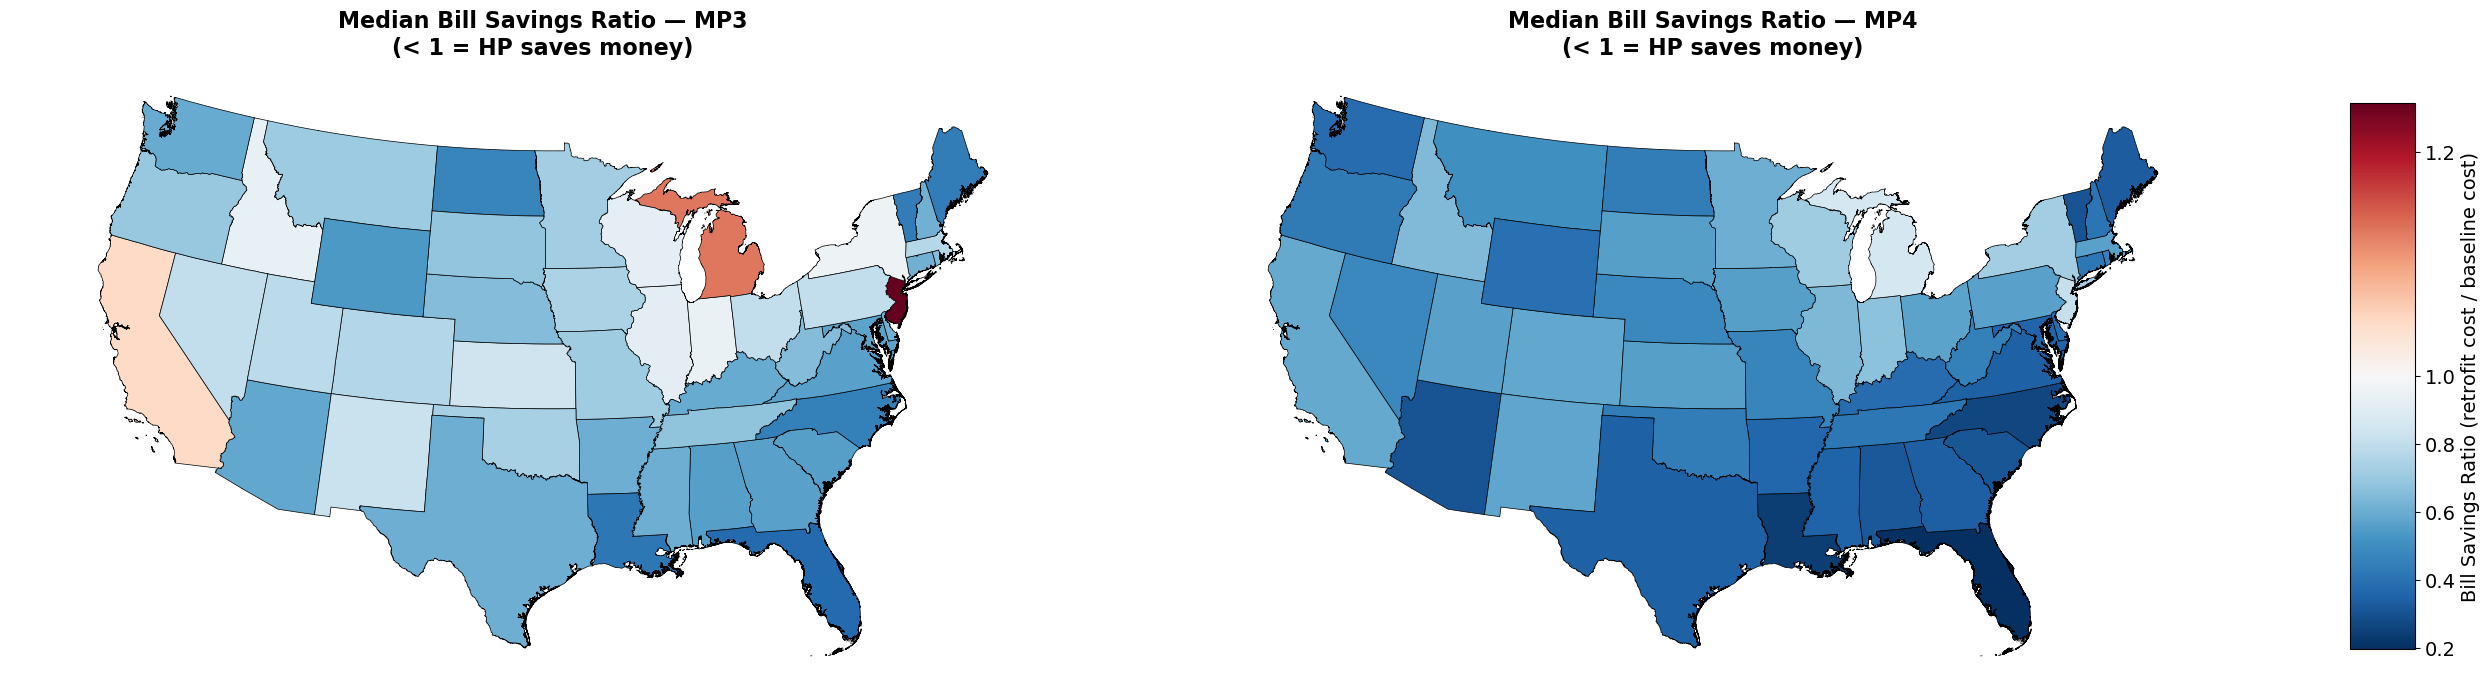

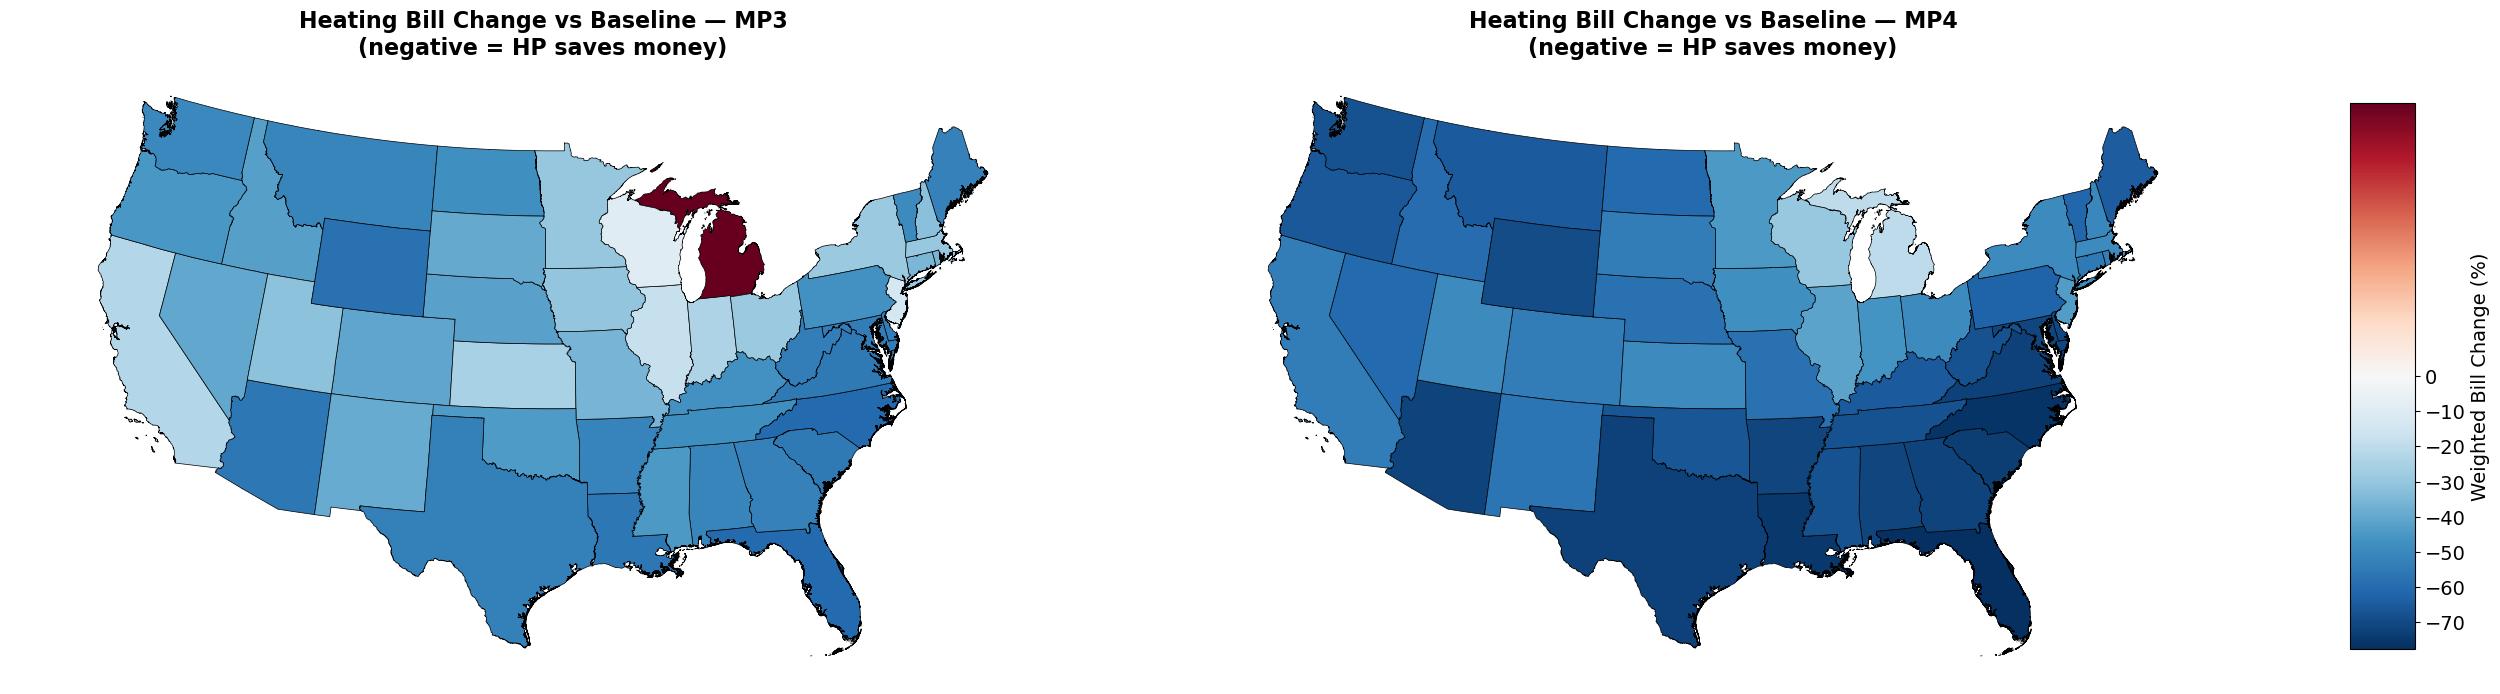

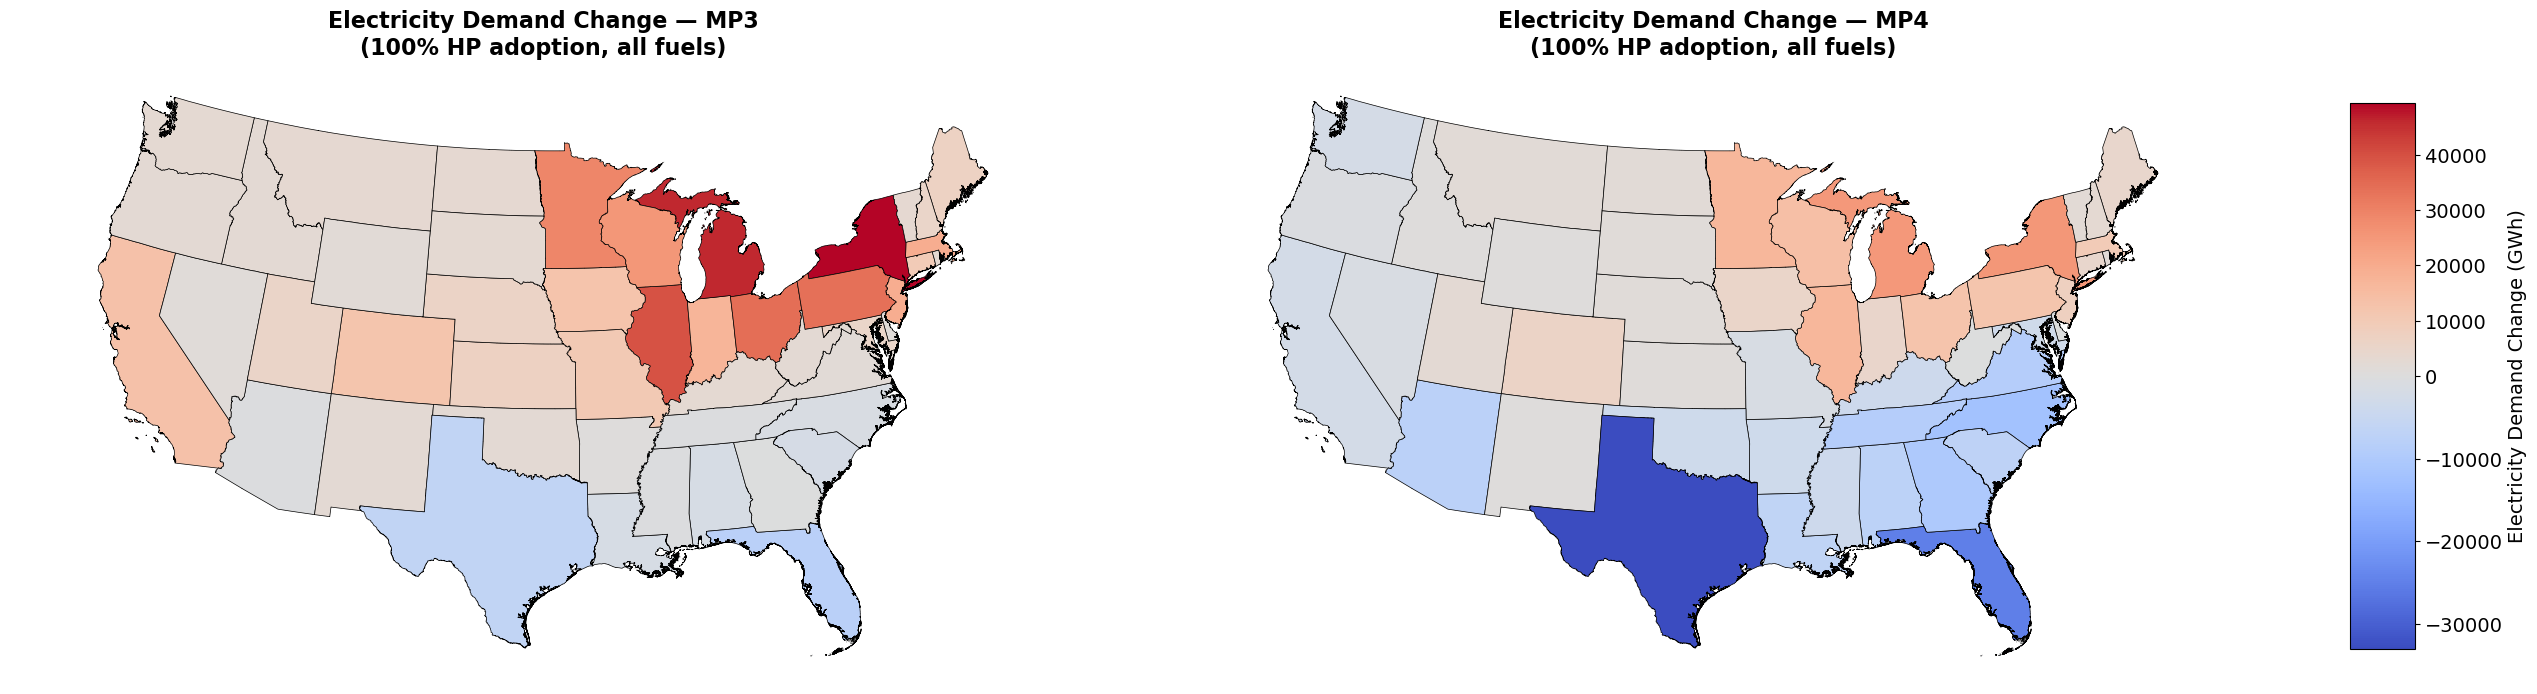

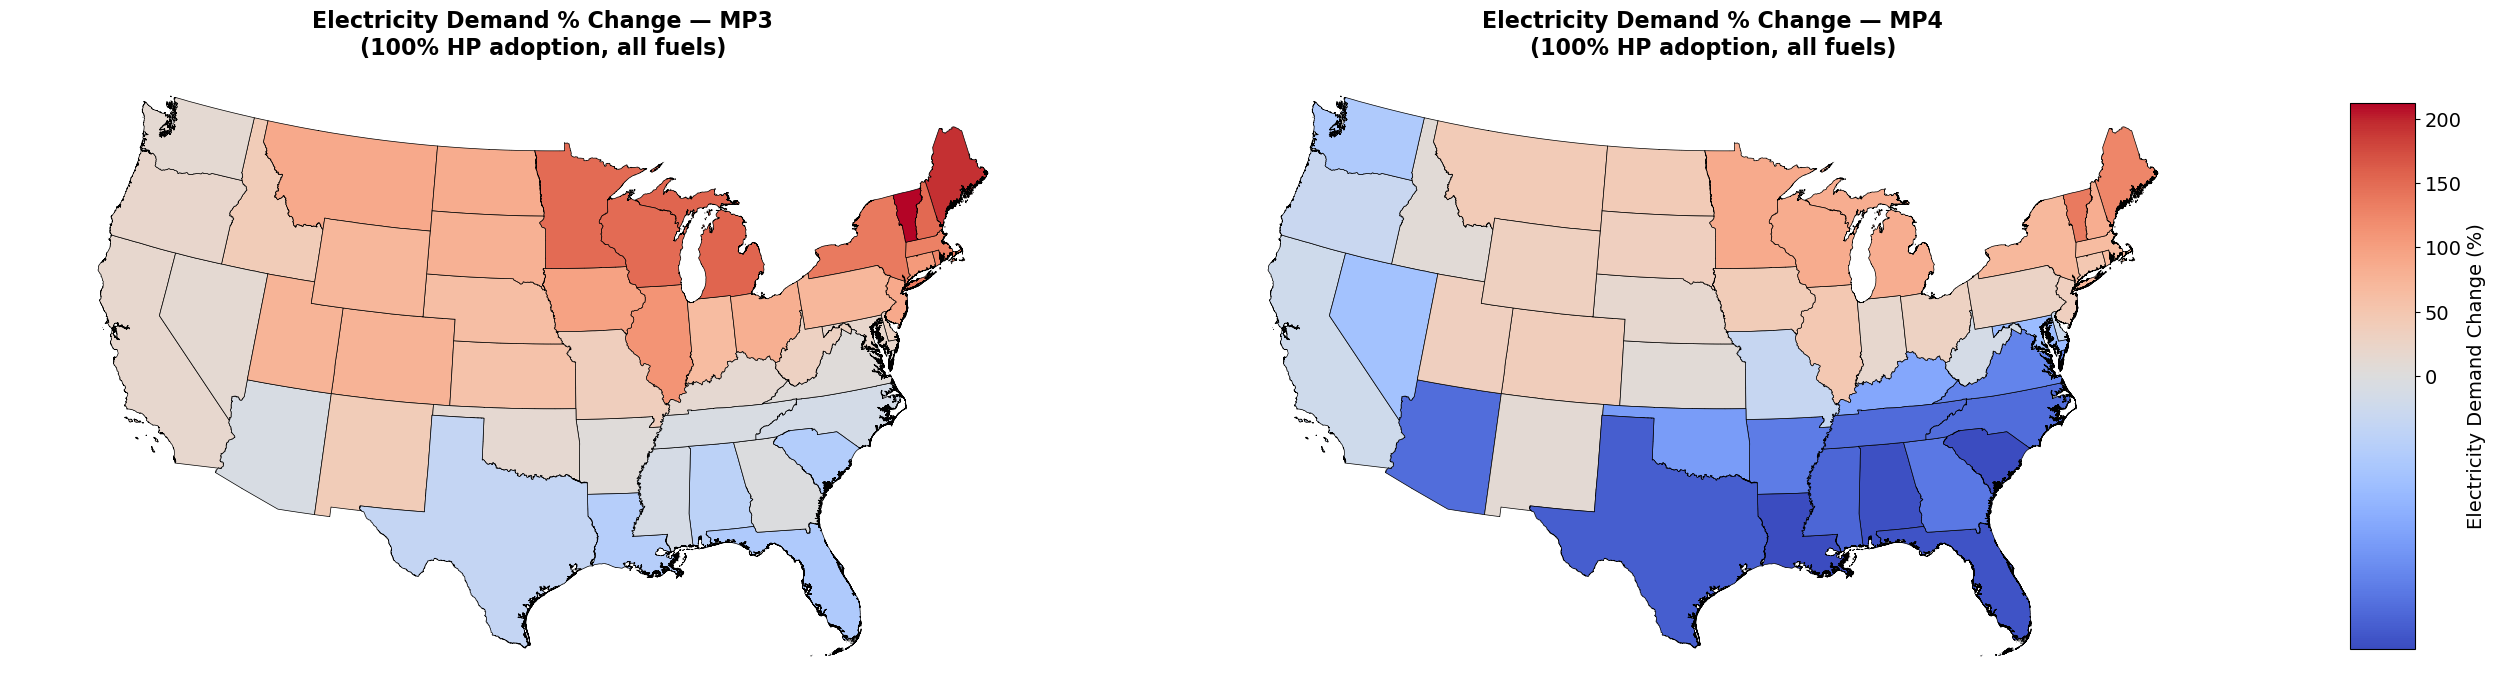

[OK] All maps generated


In [9]:
gdf_states_raw = None
try:
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    print(f"[OK] Shapefile loaded: {len(gdf_states_raw)} features")
except Exception as e:
    print(f"[WARN] Shapefile not loaded: {e} — skipping maps")

if gdf_states_raw is not None:
    # ---- Add pct_bill_change to each bill_savings_results df ----
    for mp in selected_mps:
        df = bill_savings_results[mp]
        if 'pct_bill_change' not in df.columns:
            df['pct_bill_change'] = (df['weighted_ratio'] - 1) * 100

    # ---- Compute shared norms BEFORE any maps ----

    # 1. Bill savings ratio (vcenter=1.0)
    all_ratio_vals = pd.concat([
        bill_savings_results[mp]['median_bill_savings_ratio']
        for mp in selected_mps
    ]).dropna()
    r_min = min(all_ratio_vals.min(), 0.999)
    r_max = max(all_ratio_vals.max(), 1.001)
    shared_ratio_norm = mcolors.TwoSlopeNorm(vmin=r_min, vcenter=1.0, vmax=r_max)
    print(f"Bill savings ratio norm: [{r_min:.3f}, 1.0, {r_max:.3f}]")

    # 2. Bill savings percent change (vcenter=0)
    all_pct_bill_vals = pd.concat([
        bill_savings_results[mp]['pct_bill_change']
        for mp in selected_mps
    ]).dropna()
    pb_min = min(all_pct_bill_vals.min(), -0.01)
    pb_max = max(all_pct_bill_vals.max(), 0.01)
    shared_pct_bill_norm = mcolors.TwoSlopeNorm(vmin=pb_min, vcenter=0, vmax=pb_max)
    print(f"Bill savings % norm: [{pb_min:.1f}, 0, {pb_max:.1f}]%")

    # 3. Electricity demand change GWh (vcenter=0)
    all_demand_vals = pd.concat([
        demand_results[mp]['elec_change_gwh']
        for mp in selected_mps
    ]).dropna()
    d_min = min(all_demand_vals.min(), -0.01)
    d_max = max(all_demand_vals.max(), 0.01)
    shared_demand_norm = mcolors.TwoSlopeNorm(vmin=d_min, vcenter=0, vmax=d_max)
    print(f"Demand GWh norm: [{d_min:.1f}, 0, {d_max:.1f}] GWh")

    # 4. Electricity demand percent change (vcenter=0)
    all_pct_demand_vals = pd.concat([
        demand_results[mp]['pct_elec_demand_change']
        for mp in selected_mps
    ]).dropna()
    pd_min = min(all_pct_demand_vals.min(), -0.01)
    pd_max = max(all_pct_demand_vals.max(), 0.01)
    shared_pct_demand_norm = mcolors.TwoSlopeNorm(vmin=pd_min, vcenter=0, vmax=pd_max)
    print(f"Demand % norm: [{pd_min:.1f}, 0, {pd_max:.1f}]%")

    # ---- Map 1: Bill savings ratio ----
    plot_combined_choropleth(
        gdf_states_raw, bill_savings_results,
        column='median_bill_savings_ratio',
        title_template='Median Bill Savings Ratio — MP{mp}\n(< 1 = HP saves money)',
        cbar_label='Bill Savings Ratio (retrofit cost / baseline cost)',
        cmap='RdBu_r', norm=shared_ratio_norm, selected_mps=selected_mps,
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'state_bill_savings_ratio_combined.png'),
    )

    # ---- Map 2: Bill savings percent change ----
    plot_combined_choropleth(
        gdf_states_raw, bill_savings_results,
        column='pct_bill_change',
        title_template='Heating Bill Change vs Baseline — MP{mp}\n(negative = HP saves money)',
        cbar_label='Weighted Bill Change (%)',
        cmap='RdBu_r', norm=shared_pct_bill_norm, selected_mps=selected_mps,
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'state_bill_pct_change_combined.png'),
    )

    # ---- Map 3: Electricity demand change (GWh) ----
    plot_combined_choropleth(
        gdf_states_raw, demand_results,
        column='elec_change_gwh',
        title_template='Electricity Demand Change — MP{mp}\n(100% HP adoption, all fuels)',
        cbar_label='Electricity Demand Change (GWh)',
        cmap='coolwarm', norm=shared_demand_norm, selected_mps=selected_mps,
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'state_elec_demand_gwh_combined.png'),
    )

    # ---- Map 4: Electricity demand percent change ----
    plot_combined_choropleth(
        gdf_states_raw, demand_results,
        column='pct_elec_demand_change',
        title_template='Electricity Demand % Change — MP{mp}\n(100% HP adoption, all fuels)',
        cbar_label='Electricity Demand Change (%)',
        cmap='coolwarm', norm=shared_pct_demand_norm, selected_mps=selected_mps,
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'state_elec_demand_pct_combined.png'),
    )

    print("[OK] All maps generated")
else:
    print("[WARN] Maps skipped")


In [10]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)

for mp in selected_mps:
    df_bs = bill_savings_results[mp]
    df_dem = demand_results[mp]
    n_savings = (df_bs['median_bill_savings_ratio'] < 1.0).sum()
    total_states = len(df_bs)
    nat_median_ratio = df_bs['median_bill_savings_ratio'].median()
    nat_median_pct = df_bs['pct_bill_change'].median()
    total_elec_gwh = df_dem['elec_change_gwh'].sum()
    median_pct_demand = df_dem['pct_elec_demand_change'].median()
    print(f"\n--- MP{mp} ---")
    print(f"Bill savings: {n_savings}/{total_states} states save money "
          f"| median ratio: {nat_median_ratio:.3f} "
          f"| median bill change: {nat_median_pct:+.1f}%")
    print(f"Demand change (all fuels): {total_elec_gwh:+.1f} GWh total "
          f"| median state % change: {median_pct_demand:+.1f}%")

print("\n[DONE]")


SUMMARY

--- MP3 ---
Bill savings: 46/49 states save money | median ratio: 0.653 | median bill change: -44.6%
Demand change (all fuels): +427043.7 GWh total | median state % change: +44.1%

--- MP4 ---
Bill savings: 49/49 states save money | median ratio: 0.440 | median bill change: -61.7%
Demand change (all fuels): +30618.3 GWh total | median state % change: +8.2%

[DONE]
